## Modelling

In [63]:
# --------------------------------
# IMPORTS
# --------------------------------

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, r2_score, root_mean_squared_error
from sklearn.model_selection import TimeSeriesSplit, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.tree import plot_tree
from xgboost import XGBRegressor


In [64]:
# --------------------------------
# PRESENTATION STYLE
# --------------------------------

sns.set_theme(
    style="whitegrid",
    context="talk"
)

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["axes.titlesize"] = 18
plt.rcParams["axes.labelsize"] = 14
plt.rcParams["xtick.labelsize"] = 11
plt.rcParams["ytick.labelsize"] = 11

In [65]:
# --------------------------------
# HELPER MODEL EVALUATION
# --------------------------------

def evaluate_model(model_name, model, X_train, y_train, X_test, y_test):

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    metrics = {
        "model": model_name,
        "R2": r2_score(y_test, y_pred),
        "MAE": mean_absolute_error(y_test, y_pred),
        "RMSE": root_mean_squared_error(y_test, y_pred)
    }

    return metrics, y_pred

In [66]:
# --------------------------------
# LOAD PROCESSED DATA
# --------------------------------

df = pd.read_csv('../01_data/02_processed_data/hour.csv')

df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt,log_cnt,temp_diff,time_of_day
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16,2.833213,-0.0479,night
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40,3.713572,-0.0527,night
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32,3.496508,-0.0527,night
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13,2.639057,-0.0479,night
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1,0.693147,-0.0479,night


In [67]:
# --------------------------------
# TRAIN TEST SPLIT
# --------------------------------

df["dteday"] = pd.to_datetime(df["dteday"])

df = df.sort_values(["dteday", "hr"]).reset_index(drop=True)

split_idx = int(len(df) * 0.8)

split_date = df.loc[split_idx, "dteday"]

df_train = df[df["dteday"] < split_date].copy()
df_test = df[df["dteday"] >= split_date].copy()

print("Train:", df_train.shape)
print("Test:", df_test.shape)

print(
    "Train Zeitraum:",
    df_train["dteday"].min(),
    "bis",
    df_train["dteday"].max()
)

print(
    "Test Zeitraum:",
    df_test["dteday"].min(),
    "bis",
    df_test["dteday"].max()
)


Train: (13891, 20)
Test: (3488, 20)
Train Zeitraum: 2011-01-01 00:00:00 bis 2012-08-06 00:00:00
Test Zeitraum: 2012-08-07 00:00:00 bis 2012-12-31 00:00:00


In [68]:
# --------------------------------
# FEATURES SELECTIONS BASELINE
# --------------------------------

FEATURES_BASELINE = {
    'season': 'categorical',
    'yr': 'binary',
    'mnth': 'categorical',
    'hr': 'categorical',
    'holiday': 'binary',
    'weekday': 'categorical',
    'workingday': 'binary',
    'weathersit': 'categorical',
    'temp': 'numerical',
    'hum': 'numerical',
    'windspeed': 'numerical',
}


target_original = df['cnt']
target_log = df['log_cnt']



## Baseline Model

In [69]:
# --------------------------------
# RANDOM FOREST REGRESSOR - BASELINE
# --------------------------------

# Note:
# For the baseline model, a time-based holdout test split was initially used.
# Cross-validation is then used to compare model variants and tune hyperparameters.


# --------------------------------
# FEATURE GROUPS
# --------------------------------

categorical_features_baseline = [
    feature
    for feature, feature_type in FEATURES_BASELINE.items()
    if feature_type == "categorical"
]

binary_features_baseline = [
    feature
    for feature, feature_type in FEATURES_BASELINE.items()
    if feature_type == "binary"
]

numerical_features_baseline = [
    feature
    for feature, feature_type in FEATURES_BASELINE.items()
    if feature_type == "numerical"
]


# --------------------------------
# TRAIN / TEST DATA
# --------------------------------

feature_columns = list(FEATURES_BASELINE.keys())

X_train = df_train[feature_columns]
y_train = df_train["cnt"]

X_test = df_test[feature_columns]
y_test = df_test["cnt"]


# --------------------------------
# PREPROCESSING
# --------------------------------

ct_baseline = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features_baseline
        ),
        (
            "bin",
            "passthrough",
            binary_features_baseline
        ),
        (
            "num",
            "passthrough",
            numerical_features_baseline
        ),
    ]
)


# --------------------------------
# MODEL
# --------------------------------

rfr_baseline = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# --------------------------------
# PIPELINE
# --------------------------------

pipeline_baseline = Pipeline([
    ("preprocess", ct_baseline),
    ("model", rfr_baseline)
])


# --------------------------------
# TRAIN & EVALUATE
# --------------------------------

metrics_rfr_baseline, target_test_original_pred = evaluate_model(
    "RF Baseline",
    pipeline_baseline,
    X_train,
    y_train,
    X_test,
    y_test
)

print(metrics_rfr_baseline)

{'model': 'RF Baseline', 'R2': 0.8622035838774824, 'MAE': 54.56906510416666, 'RMSE': 81.84898147844295}


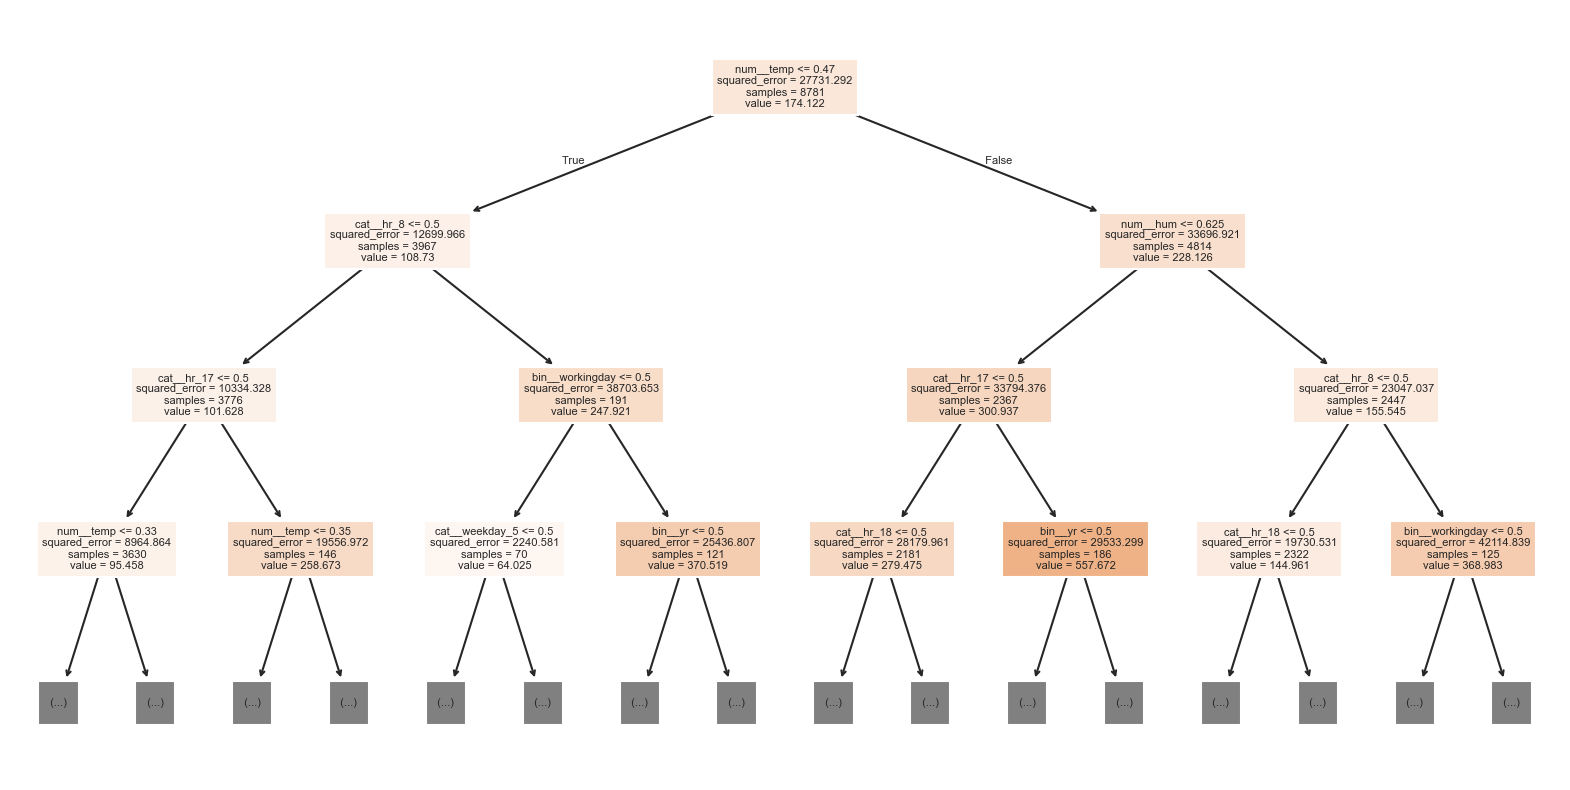

In [70]:
rfr_model = pipeline_baseline.named_steps["model"]


plt.figure(figsize=(20, 10))

plot_tree(
    rfr_model.estimators_[0],
    max_depth=3,
    filled=True,
    feature_names=pipeline_baseline.named_steps["preprocess"].get_feature_names_out(),
    fontsize=8
)

plt.show()

In [71]:
rfr_model = pipeline_baseline.named_steps["model"]
preprocessor = pipeline_baseline.named_steps["preprocess"]

feature_names = preprocessor.get_feature_names_out()
importance = rfr_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
}).sort_values("importance", ascending=False)

print(feature_importance.head(20))

            feature  importance
54        num__temp    0.181106
55         num__hum    0.138047
53  bin__workingday    0.085973
33       cat__hr_17    0.083888
34       cat__hr_18    0.074374
51          bin__yr    0.062940
24        cat__hr_8    0.062107
35       cat__hr_19    0.032374
23        cat__hr_7    0.018266
17        cat__hr_1    0.016091
18        cat__hr_2    0.015625
56   num__windspeed    0.015522
19        cat__hr_3    0.014591
16        cat__hr_0    0.014241
20        cat__hr_4    0.014088
32       cat__hr_16    0.013528
21        cat__hr_5    0.013064
36       cat__hr_20    0.012172
39       cat__hr_23    0.010881
25        cat__hr_9    0.010876


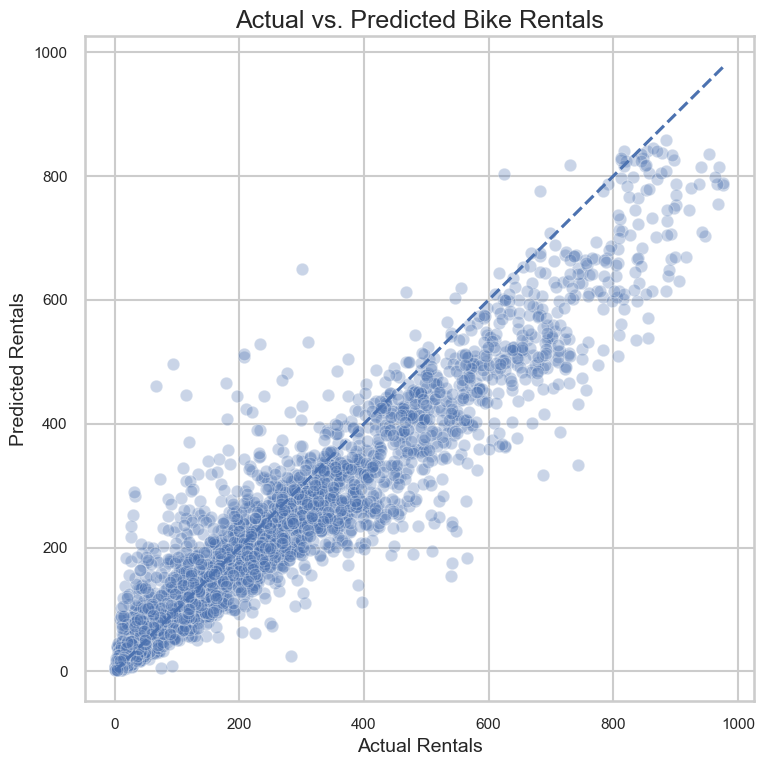

In [72]:
# --------------------------------
# ACTUAL VS PREDICTED
# --------------------------------

plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=df_test["cnt"],
    y=target_test_original_pred,
    alpha=0.3
)

min_value = min(
    df_test["cnt"].min(),
    target_test_original_pred.min()
)

max_value = max(
    df_test["cnt"].max(),
    target_test_original_pred.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("Actual vs. Predicted Bike Rentals")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")

plt.tight_layout()
plt.show()

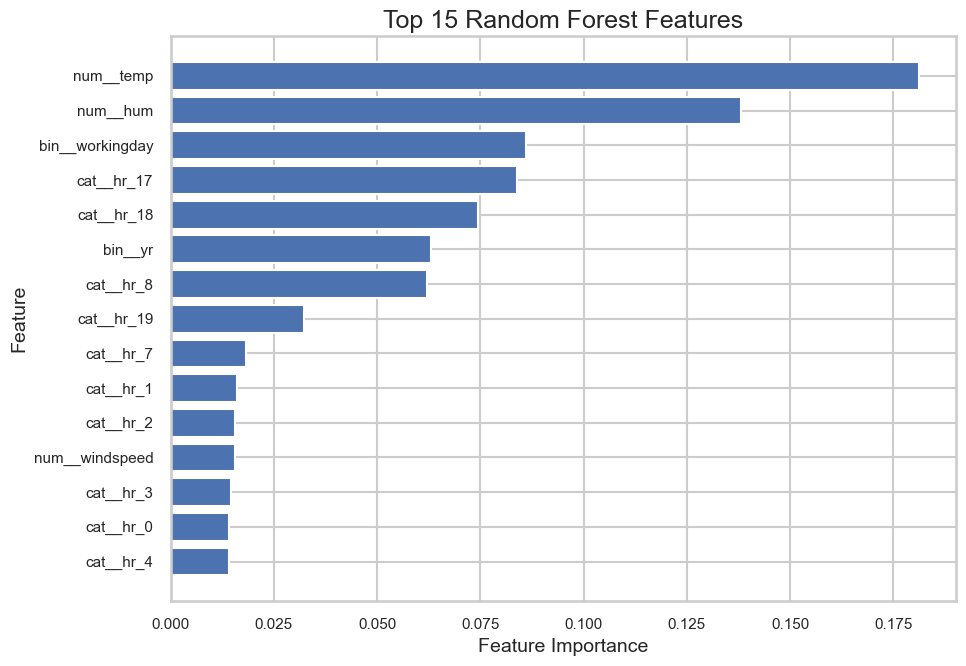

In [73]:
# --------------------------------
# RANDOM FOREST FEATURE IMPORTANCE
# --------------------------------

rfr_model = pipeline_baseline.named_steps["model"]
preprocessor = pipeline_baseline.named_steps["preprocess"]

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance = rfr_model.feature_importances_

feature_importance = (
    pd.DataFrame({
        "feature": feature_names,
        "importance": importance
    })
    .sort_values(
        "importance",
        ascending=False
    )
    .head(15)
    .sort_values(
        "importance"
    )
)

plt.figure(figsize=(10, 7))

plt.barh(
    feature_importance["feature"],
    feature_importance["importance"]
)

plt.title("Top 15 Random Forest Features")
plt.xlabel("Feature Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [74]:
# --------------------------------
# GROUPED FEATURE IMPORTANCE
# --------------------------------

rfr_model = pipeline_baseline.named_steps["model"]
preprocessor = pipeline_baseline.named_steps["preprocess"]

feature_names = preprocessor.get_feature_names_out()
importance = rfr_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

feature_importance["original_feature"] = (
    feature_importance["feature"]
    .str.replace(r"^(cat|bin|num)__", "", regex=True)
    .str.extract(r"^([a-zA-Z_]+)", expand=False)
)

for feature in categorical_features_baseline:
    feature_importance.loc[
        feature_importance["feature"].str.startswith(f"cat__{feature}_"),
        "original_feature"
    ] = feature

for feature in binary_features_baseline + numerical_features_baseline:
    feature_importance.loc[
        feature_importance["feature"].eq(f"bin__{feature}") |
        feature_importance["feature"].eq(f"num__{feature}"),
        "original_feature"
    ] = feature

grouped_importance = (
    feature_importance
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

display(grouped_importance)

original_feature
hr            0.447805
temp          0.181106
hum           0.138047
workingday    0.085973
yr            0.062940
weekday       0.019417
mnth          0.017125
season        0.017055
windspeed     0.015522
weathersit    0.013842
holiday       0.001169
Name: importance, dtype: float64

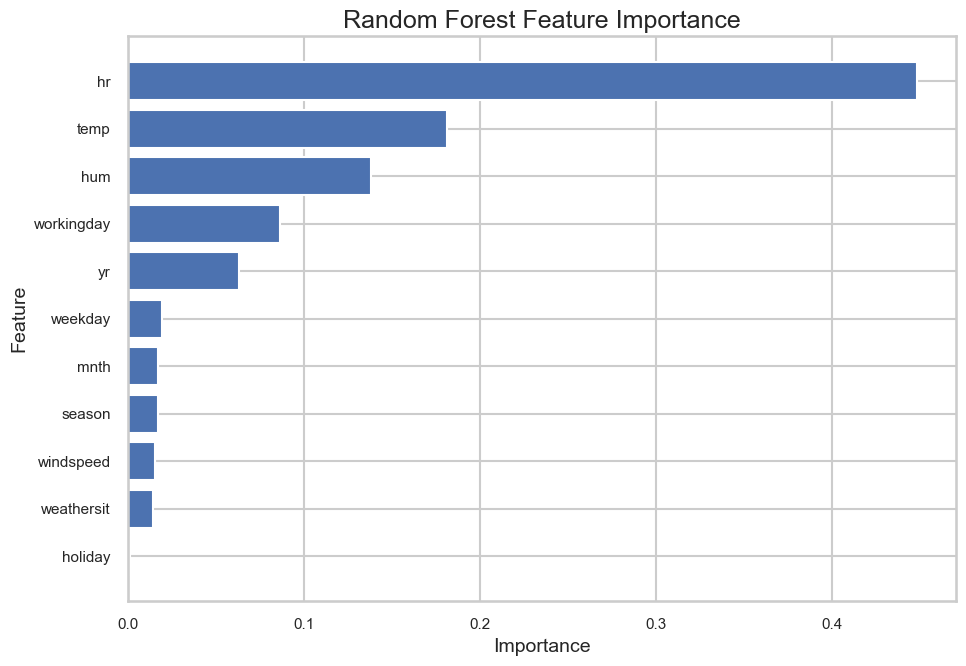

In [75]:
# --------------------------------
# GROUPED FEATURE IMPORTANCE PLOT
# --------------------------------

plot_data = (
    grouped_importance
    .sort_values(ascending=True)
)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data.index,
    plot_data.values
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

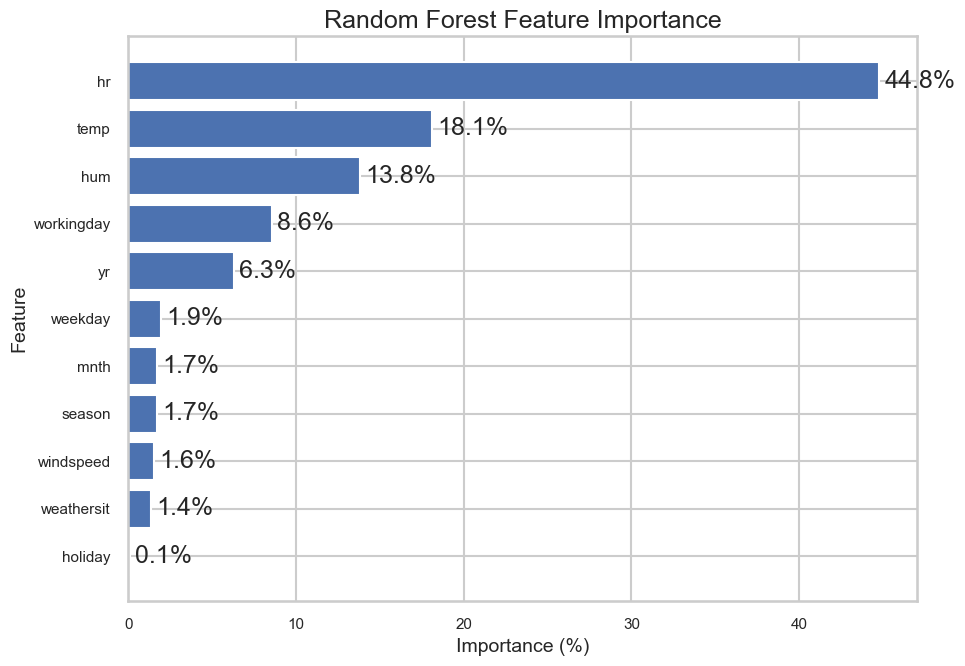

In [76]:
grouped_importance_pct = (
    grouped_importance / grouped_importance.sum() * 100
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    grouped_importance_pct.index,
    grouped_importance_pct.values
)

plt.title("Random Forest Feature Importance")
plt.xlabel("Importance (%)")
plt.ylabel("Feature")

for bar, value in zip(bars, grouped_importance_pct.values):
    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

## Feature engineered models

In [77]:
# --------------------------------
# FEATURE COLUMNS v01
# --------------------------------

FEATURES_V01 = {
    'season': 'categorical',
    'yr': 'binary',
    'mnth': 'categorical',
    'hr': 'categorical',
    'time_of_day': 'categorical',          # new feature 
    'holiday': 'binary',
    'weekday': 'categorical',
    'workingday': 'binary',
    'weathersit': 'categorical',
    'temp': 'numerical',
    'temp_diff': 'numerical',             # new feature
    'hum': 'numerical',
    'windspeed': 'numerical',
}


categorical_features = [
    feature
    for feature, feature_type in FEATURES_V01.items()
    if feature_type == "categorical"
]

binary_features = [
    feature
    for feature, feature_type in FEATURES_V01.items()
    if feature_type == "binary"
]

numerical_features = [
    feature
    for feature, feature_type in FEATURES_V01.items()
    if feature_type == "numerical"
]

feature_columns = list(FEATURES_V01.keys())


X_train_v01 = df_train[feature_columns]
y_train = df_train["cnt"]

X_test_v01 = df_test[feature_columns]
y_test = df_test["cnt"]


In [78]:
# --------------------------------
# MODELL DEFINITIONS
# --------------------------------

# Random Forest
rfr_01 = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)


# Linear Regression
reg_01 = LinearRegression()


# XGBoost
xgb_01 = XGBRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Model collection
models = {
    "Random Forest": rfr_01,
    "Linear Regression": reg_01,
    "XGBoost": xgb_01
}

In [79]:
# Random Forest
ct_rfr = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", "passthrough", numerical_features),
    ]
)

pipeline_rfr = Pipeline([
    ("preprocess", ct_rfr),
    ("model", rfr_01)
])


# Linear Regression
ct_reg = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", StandardScaler(), numerical_features),
    ]
)

pipeline_reg = Pipeline([
    ("preprocess", ct_reg),
    ("model", reg_01)
])


# XGBoost
ct_xgb = ColumnTransformer(
    transformers=[
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
        ("bin", "passthrough", binary_features),
        ("num", "passthrough", numerical_features),
    ]
)

pipeline_xgb = Pipeline([
    ("preprocess", ct_xgb),
    ("model", xgb_01)
])

In [80]:
# --------------------------------
# OVERVIEW METRICS
# --------------------------------

results = []

metrics_rfr, y_pred_rfr = evaluate_model(
    "Random Forest",
    pipeline_rfr,
    X_train_v01,
    y_train,
    X_test_v01,
    y_test
)

results.append(metrics_rfr)

metrics_reg, y_pred_reg = evaluate_model(
    "Linear Regression",
    pipeline_reg,
    X_train_v01,
    y_train,
    X_test_v01,
    y_test
)

results.append(metrics_reg)

metrics_xgb, y_pred_xgb = evaluate_model(
    "XGBoost",
    pipeline_xgb,
    X_train_v01,
    y_train,
    X_test_v01,
    y_test
)

results.append(metrics_xgb)

results_df = pd.DataFrame(results)

display(
    results_df.sort_values(
        "RMSE",
        ascending=True
    )
)

,model,R2,MAE,RMSE
2,XGBoost,0.897240,47.351967,70.681519
0,Random Forest,0.880306,50.386929,76.283458
1,Linear Regression,0.631556,98.870708,133.838200


- Over the specified test period, XGBoost achieves the best performance to date. 

- Feature engineering further improves upon the random forest baseline.

- No follow up on Linear Regression

In [81]:
tscv = TimeSeriesSplit(n_splits=5)

In [82]:
# RandomForestRegressor

cv_rfr = cross_validate(
    pipeline_rfr,
    X_train_v01,
    y_train,
    cv=tscv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    return_train_score=False,
    error_score="raise",
)

print("RF Engineered")
print("Mean R2:", cv_rfr["test_r2"].mean())
print("Mean MAE:", -cv_rfr["test_mae"].mean())
print("Mean RMSE:", -cv_rfr["test_rmse"].mean())

RF Engineered
Mean R2: 0.732519131122449
Mean MAE: 53.92847737940965
Mean RMSE: 80.80794071075977


In [83]:
# XGBoost

cv_xgb = cross_validate(
    pipeline_xgb,
    X_train_v01,
    y_train,
    cv=tscv,
    scoring={
        "r2": "r2",
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
    },
    return_train_score=False,
    error_score="raise",
)

print("XGBoost")
print("Mean R2:", cv_xgb["test_r2"].mean())
print("Mean MAE:", -cv_xgb["test_mae"].mean())
print("Mean RMSE:", -cv_xgb["test_rmse"].mean())

XGBoost
Mean R2: 0.7610895037651062
Mean MAE: 51.04845504760742
Mean RMSE: 75.7870101928711


In [84]:
cv_xgb_df = pd.DataFrame({
    "fold": range(1, len(cv_xgb["test_r2"]) + 1),
    "R2": cv_xgb["test_r2"],
    "MAE": -cv_xgb["test_mae"],
    "RMSE": -cv_xgb["test_rmse"]
})

display(cv_xgb_df.round(3))

,fold,R2,MAE,RMSE
0,1,0.594,66.680,95.057
1,2,0.849,36.872,57.164
2,3,0.722,41.289,62.480
3,4,0.748,62.115,93.296
4,5,0.893,48.286,70.939


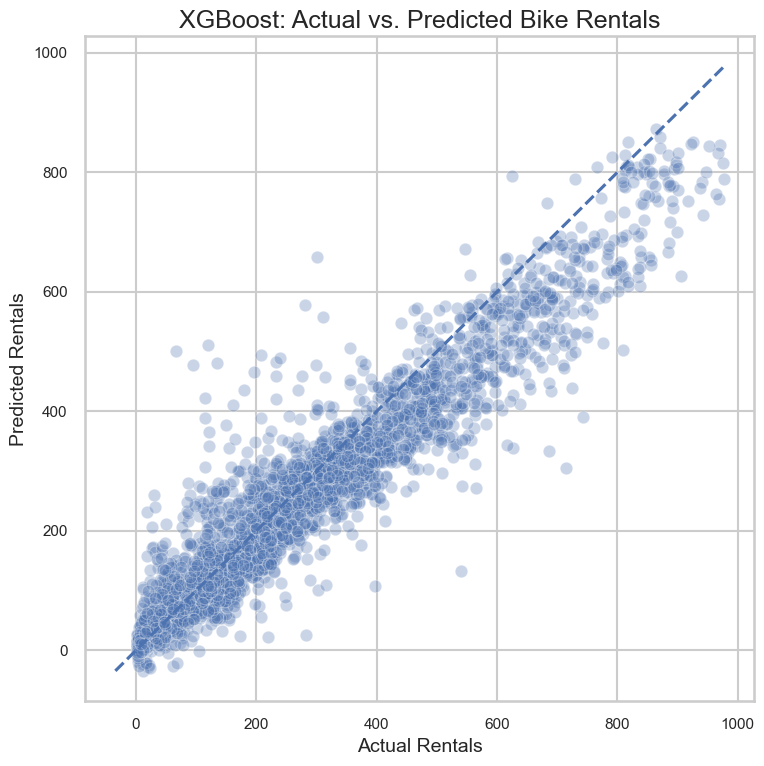

In [85]:
# --------------------------------
# ACTUAL VS PREDICTED - XGBOOST
# --------------------------------

plt.figure(figsize=(8, 8))

sns.scatterplot(
    x=y_test,
    y=y_pred_xgb,
    alpha=0.3
)

min_value = min(
    y_test.min(),
    y_pred_xgb.min()
)

max_value = max(
    y_test.max(),
    y_pred_xgb.max()
)

plt.plot(
    [min_value, max_value],
    [min_value, max_value],
    linestyle="--"
)

plt.title("XGBoost: Actual vs. Predicted Bike Rentals")
plt.xlabel("Actual Rentals")
plt.ylabel("Predicted Rentals")

plt.tight_layout()
plt.show()

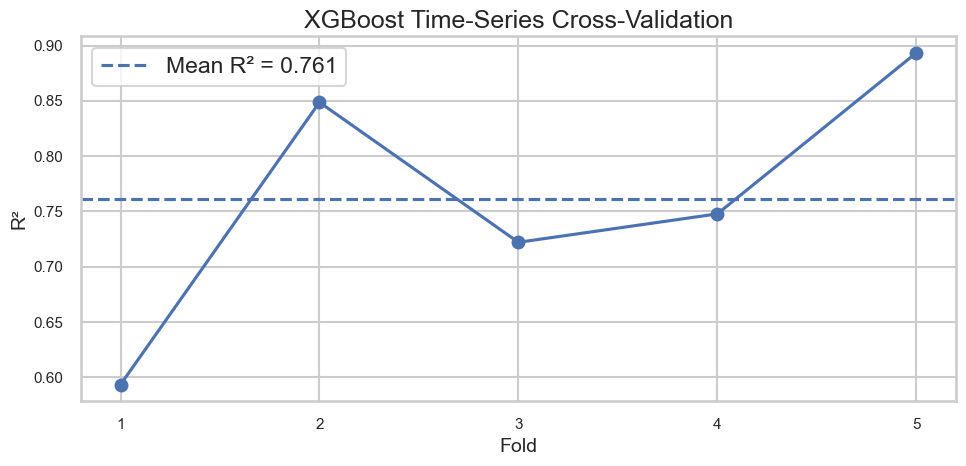

In [86]:
cv_plot = cv_xgb_df.copy()

plt.figure(figsize=(10, 5))

plt.plot(
    cv_plot["fold"],
    cv_plot["R2"],
    marker="o"
)

plt.axhline(
    cv_plot["R2"].mean(),
    linestyle="--",
    label=f"Mean R² = {cv_plot['R2'].mean():.3f}"
)

plt.title("XGBoost Time-Series Cross-Validation")
plt.xlabel("Fold")
plt.ylabel("R²")

plt.xticks(cv_plot["fold"])

plt.legend()

plt.tight_layout()
plt.show()

In [87]:
# --------------------------------
# GROUPED FEATURE IMPORTANCE
# XGBoost
# --------------------------------

xgb_model = pipeline_xgb.named_steps["model"]
preprocessor = pipeline_xgb.named_steps["preprocess"]

feature_names = (
    preprocessor
    .get_feature_names_out()
)

importance = xgb_model.feature_importances_

feature_importance = pd.DataFrame({
    "feature": feature_names,
    "importance": importance
})

# Remove preprocessing prefixes
feature_importance["original_feature"] = (
    feature_importance["feature"]
    .str.replace(r"^(cat|bin|num)__", "", regex=True)
)

# Map one-hot encoded categorical features back
for feature in categorical_features:
    feature_importance.loc[
        feature_importance["feature"].str.startswith(
            f"cat__{feature}_"
        ),
        "original_feature"
    ] = feature

# Group importances
grouped_importance = (
    feature_importance
    .groupby("original_feature")["importance"]
    .sum()
    .sort_values(ascending=False)
)

display(grouped_importance)

original_feature
hr             0.449648
time_of_day    0.403690
workingday     0.032922
yr             0.025616
season         0.021469
temp           0.021200
weathersit     0.013562
mnth           0.012533
weekday        0.010480
hum            0.005242
holiday        0.001635
windspeed      0.001044
temp_diff      0.000959
Name: importance, dtype: float32

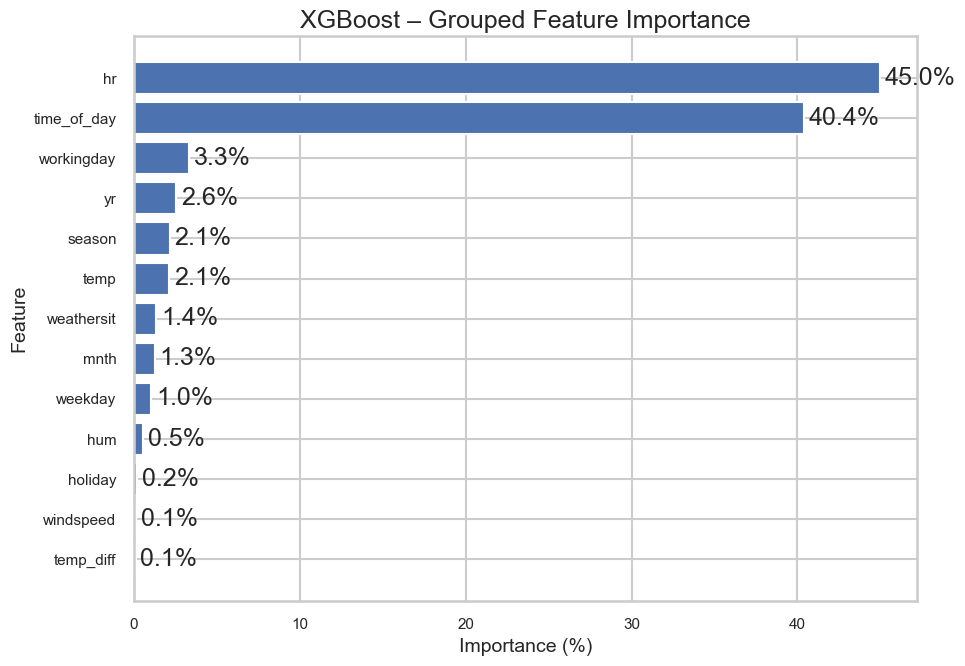

In [88]:
# --------------------------------
# PLOT GROUPED FEATURE IMPORTANCE
# --------------------------------

grouped_importance_pct = (
    grouped_importance / grouped_importance.sum() * 100
).sort_values(ascending=True)

plt.figure(figsize=(10, 7))

bars = plt.barh(
    grouped_importance_pct.index,
    grouped_importance_pct.values
)

plt.title("XGBoost – Grouped Feature Importance")
plt.xlabel("Importance (%)")
plt.ylabel("Feature")

for bar, value in zip(
    bars,
    grouped_importance_pct.values
):
    plt.text(
        value + 0.3,
        bar.get_y() + bar.get_height() / 2,
        f"{value:.1f}%",
        va="center"
    )

plt.tight_layout()
plt.show()

## Results
- XGBoost was selected as the final model because of its superior predictive performance, its ability to model nonlinear relationships, and its robust performance in time-based cross-validation.
- XGBoost achieves an R² of 0.897 in the time-based holdout test. The time-series cross-validation shows an average performance of R² = 0.761, 
with significant fluctuations between time periods. This makes XGBoost the strongest model tested overall; however, its performance varies over time.
- The newly developed feature, `time_of_day`, improves the cross-validation performance of the XGBoost model. The mean R² increases from 0.739 to 0.761, while MAE and RMSE decrease. Some of this information is already contained in hr; however, the coarser time segmentation provides additional information for the model.
- Time-related features dominate the XGBoost model. Hour of day and the aggregated time-of-day feature together account for approximately 85 % of the model's feature importance.
- Future ideas: log target version, test model without low important features.